In [1]:
import pandas as pd
import numpy as np

### DATA UNDERSTANDING

#### Data Import and Cleaning Process

In [2]:
data = pd.read_csv(
    r'C:\Users\Fadlilah\Downloads\Strategic_Growth_Insights.csv',
    encoding='latin1'
)

data.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,ad_platform,ad_type,...,user_age,age_group,country,location,interests,name,start_date,end_date,duration_days,total_budget
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,9,Facebook,Stories,...,24,18-24,United States,West Shawna,"gaming, food",Campaign_9_Launch,2025-05-25,2025-07-13,49,40094.07
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,26,Instagram,Carousel,...,30,25-34,United States,Meyersland,"photography, finance",Campaign_26_Winter,2025-04-01,2025-06-17,77,44538.87
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,10,Instagram,Carousel,...,20,18-24,United States,Barrerahaven,"fashion, sports, travel",Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,14,Instagram,Image,...,18,18-24,United States,Lake Angelaland,"food, art",Campaign_14_Summer,2025-04-15,2025-06-04,50,39849.94
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,2,Instagram,Stories,...,58,55-65,United Kingdom,Robinsonberg,"finance, lifestyle",Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   event_id          100000 non-null  int64  
 1   ad_id             100000 non-null  int64  
 2   user_id           100000 non-null  object 
 3   timestamp         100000 non-null  object 
 4   day_of_week       100000 non-null  object 
 5   time_of_day       100000 non-null  object 
 6   event_type        100000 non-null  object 
 7   campaign_id       100000 non-null  int64  
 8   ad_platform       100000 non-null  object 
 9   ad_type           100000 non-null  object 
 10  target_gender     100000 non-null  object 
 11  target_age_group  100000 non-null  object 
 12  target_interests  100000 non-null  object 
 13  user_gender       100000 non-null  object 
 14  user_age          100000 non-null  int64  
 15  age_group         100000 non-null  object 
 16  country           100

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
missing = data.isnull().sum()
missing

event_id            0
ad_id               0
user_id             0
timestamp           0
day_of_week         0
time_of_day         0
event_type          0
campaign_id         0
ad_platform         0
ad_type             0
target_gender       0
target_age_group    0
target_interests    0
user_gender         0
user_age            0
age_group           0
country             0
location            0
interests           0
name                0
start_date          0
end_date            0
duration_days       0
total_budget        0
dtype: int64

In [6]:
for col in data.columns:
    print(f"\nkolom:{col}")
    print(data[col].unique())


kolom:event_id
[    1     2     3 ... 99045 99046 99047]

kolom:ad_id
[197  51  46 166  52  99  40 105 107   6  94 103 176  80 158 168  87  55
 118 173  17 114 135 154 102  22 174 155  67 196  78 143  59 127 182 112
 194  41 140  28  26 148 106  47 130 163  61  72 161  34 139 131  79  25
 156 136   1  88  12  77  16 195   2 170  44 183  37  81 124  85   5  57
 179 159  84   3 164  91 120 198 108 101  96 122 129 185  58  45 121 100
  43 180  70  56  21  68 186 126 123  30  69  76  74 104 149 171 153 187
  31  42 191  63  36 113 181 134 165 151 132 110  49  54  14  24 145   9
 111 119 152 178 160  27 146  98  10   4  11 172  92  48 169  33  82 188
 133  64  66 190  53 109  50 167 175 117  13  18 125 138  86  35 177  23
  20 200  15  83  39   8 128 150  29  97  32  95  71  19 184 189 193 147
  73  38 142 137 157  90 141  60   7 115 116  89  62 192 162 144  75  65
  93 199]

kolom:user_id
['2359b' 'f9c67' '5b868' ... 'a3f60' '8e3b0' 'eaf77']

kolom:timestamp
['2025-07-26 00:19:56' '2025-0

In [7]:
data.describe()

,event_id,ad_id,campaign_id,user_age,duration_days,total_budget
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,49511.712020,100.495500,25.121340,27.66688,66.418950,51161.670095
std,28593.758155,57.858811,13.671546,8.30493,16.762637,25503.679423
min,1.000000,1.000000,1.000000,16.00000,32.000000,7918.040000
25%,24740.750000,50.000000,13.000000,21.00000,52.000000,28962.340000
50%,49511.500000,101.000000,25.000000,27.00000,70.000000,48832.610000
75%,74276.250000,150.000000,37.000000,32.00000,82.000000,71038.280000
max,99047.000000,200.000000,50.000000,65.00000,90.000000,98904.660000


In [8]:
# Mengambil kolom kategorikal
cat_col = data.select_dtypes(include=['object']).columns

cat_info = []

for col in cat_col:
    cat_info.append({
        'column_name': col,
        'n_unique': data[col].nunique(),
        'sample_unique_values': data[col].dropna().unique()[:10].tolist()
    })

# Membuat dataframe
data_cat_info = pd.DataFrame(cat_info)

# Menampilkan
data_cat_info

,column_name,n_unique,sample_unique_values
0,user_id,9950,"[2359b, f9c67, 5b868, 3d440, 68f1a, 03834, 23e..."
1,timestamp,98428,"[2025-07-26 00:19:56, 2025-06-15 08:28:07, 202..."
2,day_of_week,7,"[Saturday, Sunday, Friday, Thursday, Tuesday, ..."
3,time_of_day,4,"[Night, Morning, Evening, Afternoon]"
4,event_type,6,"[Like, Share, Impression, Purchase, Click, Com..."
5,ad_platform,2,"[Facebook, Instagram]"
6,ad_type,4,"[Stories, Carousel, Image, Video]"
7,target_gender,3,"[All, Female, Male]"
8,target_age_group,4,"[All, 18-24, 35-44, 25-34]"
9,target_interests,90,"[lifestyle, gaming, photography, technology, t..."


In [9]:
print("===VALUE COUNTS UNTUK KOLOM KATEGORIKAL ===")
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'Date':  # Lewati kolom tanggal agar output tidak terlalu panjang
        print(f"\nValue Counts untuk kolom '{col}':")
        print(data[col].value_counts())
        print("-" * 40)

===VALUE COUNTS UNTUK KOLOM KATEGORIKAL ===

Value Counts untuk kolom 'user_id':
user_id
5bdf4    62
97409    54
49c5c    54
15f7b    50
699a5    50
         ..
4ec7c     1
9ee00     1
9024b     1
04a6b     1
eaf77     1
Name: count, Length: 9950, dtype: int64
----------------------------------------

Value Counts untuk kolom 'timestamp':
timestamp
2025-06-08 23:28:07    3
2025-07-28 00:45:10    3
2025-06-10 14:30:31    3
2025-05-10 17:56:35    3
2025-06-15 07:43:03    3
                      ..
2025-05-08 01:57:20    1
2025-07-02 04:08:32    1
2025-05-24 21:44:10    1
2025-07-30 02:00:03    1
2025-08-03 02:47:42    1
Name: count, Length: 98428, dtype: int64
----------------------------------------

Value Counts untuk kolom 'day_of_week':
day_of_week
Wednesday    14400
Friday       14329
Monday       14299
Tuesday      14290
Thursday     14253
Saturday     14222
Sunday       14207
Name: count, dtype: int64
----------------------------------------

Value Counts untuk kolom 'time_of_day'

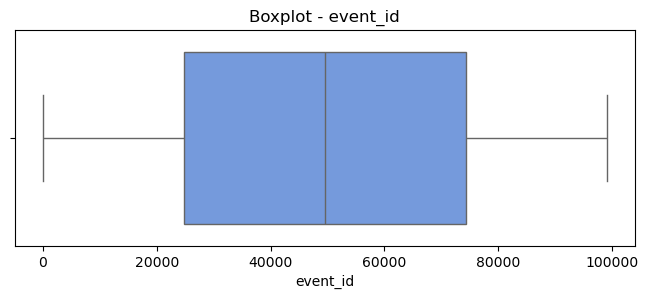

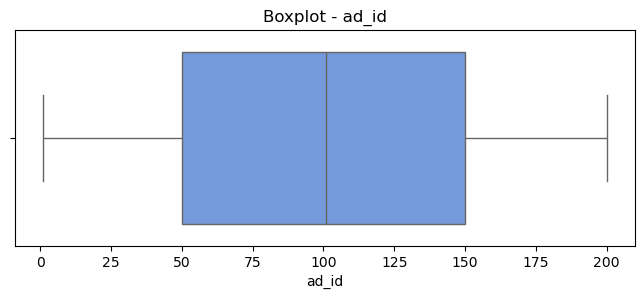

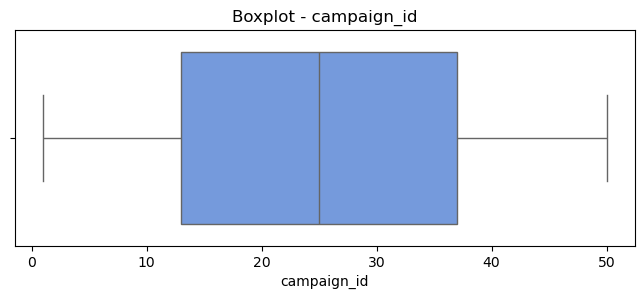

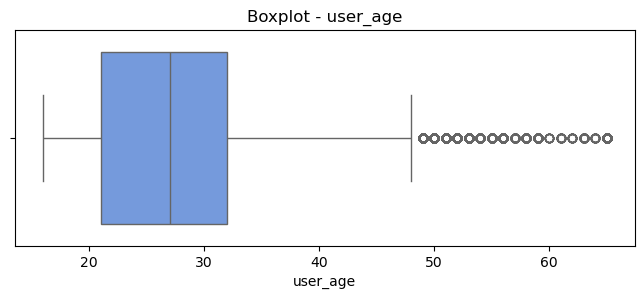

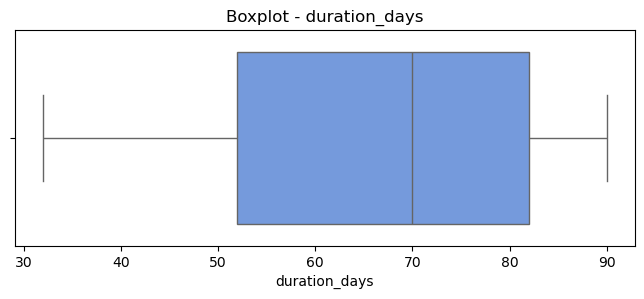

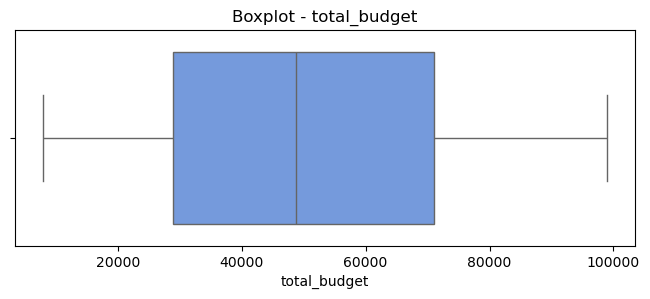

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
# Visualisasi Boxplot per Kolom Numerik

num_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(8, 2.8))
    sns.boxplot(x=data[col], color='cornflowerblue')
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

In [11]:
print("\n=== DETEKSI OUTLIER MENGGUNAKAN METODE IQR ===")
num_cols = ['event_id', 'ad_id', 'campaign_id', 'user_age', 'duration_days', 'total_budget']
outlier_indices = set()

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Mencari baris yang mengandung outlier
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"Kolom {col:18}: Ditemukan {len(outliers):} outliers (Batas: {lower_bound} s/d {upper_bound})")


=== DETEKSI OUTLIER MENGGUNAKAN METODE IQR ===
Kolom event_id          : Ditemukan 0 outliers (Batas: -49562.5 s/d 148579.5)
Kolom ad_id             : Ditemukan 0 outliers (Batas: -100.0 s/d 300.0)
Kolom campaign_id       : Ditemukan 0 outliers (Batas: -23.0 s/d 73.0)
Kolom user_age          : Ditemukan 1995 outliers (Batas: 4.5 s/d 48.5)
Kolom duration_days     : Ditemukan 0 outliers (Batas: 7.0 s/d 127.0)
Kolom total_budget      : Ditemukan 0 outliers (Batas: -34151.57000000001 s/d 134152.19)


In [12]:
#melakukan pengecekan outlier dengan metode iqr pada kolom transaction_amount
#deteksi outlier transaction_amount menggunakan iqr
Q1 = data["user_age"].quantile(0.25)
Q3 = data["user_age"].quantile(0.75)
IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outlier_user_age_iqr = data[(data["user_age"]<lower)|(data["user_age"]>upper)]
outlier_user_age_iqr

#data cleaning, melihat persentase outlier untuk menentukan apa tindakan berikutnya
jumlah_outlier = len(outlier_user_age_iqr)
print(f"jumlah outlier: {jumlah_outlier}")

#kalkulasi outlier dianggap aman
kalkulasi_outlier_age = (jumlah_outlier/100000)*100
if (jumlah_outlier/100000)*100<5:
    print(f"persentase outlier_transaction:{kalkulasi_outlier_age}%","Aman")

else:
    print(f"persentase outlier_transaction:{kalkulasi_outlier_age}%","Tdk-Aman")

jumlah outlier: 1995
persentase outlier_transaction:1.9949999999999999% Aman


In [13]:
### melakukan perbaikan type data dan standarisasi penulisan

data['timestamp'] = pd.to_datetime(data['timestamp'])
data['start_date'] = pd.to_datetime(data['start_date'])
data['end_date']   = pd.to_datetime(data['end_date'])

# 3b. Standardisasi teks (strip + title case)
cat_cols = ['day_of_week','time_of_day','event_type','ad_platform',
            'ad_type','target_gender','target_age_group','target_interests',
            'user_gender','age_group','country','location','interests','name']

for col in cat_cols:
    data[col] = data[col].astype(str).str.strip().str.title()

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   event_id          100000 non-null  int64         
 1   ad_id             100000 non-null  int64         
 2   user_id           100000 non-null  object        
 3   timestamp         100000 non-null  datetime64[ns]
 4   day_of_week       100000 non-null  object        
 5   time_of_day       100000 non-null  object        
 6   event_type        100000 non-null  object        
 7   campaign_id       100000 non-null  int64         
 8   ad_platform       100000 non-null  object        
 9   ad_type           100000 non-null  object        
 10  target_gender     100000 non-null  object        
 11  target_age_group  100000 non-null  object        
 12  target_interests  100000 non-null  object        
 13  user_gender       100000 non-null  object        
 14  user_

In [15]:
data.to_csv(r'C:\Users\Fadlilah\Downloads\strategic_growth_insights_cleaned.csv', index=False)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   event_id          100000 non-null  int64         
 1   ad_id             100000 non-null  int64         
 2   user_id           100000 non-null  object        
 3   timestamp         100000 non-null  datetime64[ns]
 4   day_of_week       100000 non-null  object        
 5   time_of_day       100000 non-null  object        
 6   event_type        100000 non-null  object        
 7   campaign_id       100000 non-null  int64         
 8   ad_platform       100000 non-null  object        
 9   ad_type           100000 non-null  object        
 10  target_gender     100000 non-null  object        
 11  target_age_group  100000 non-null  object        
 12  target_interests  100000 non-null  object        
 13  user_gender       100000 non-null  object        
 14  user_

In [17]:
pd.to_datetime(
    data['timestamp'],
    errors='coerce'
)

0       2025-07-26 00:19:56
1       2025-06-15 08:28:07
2       2025-06-27 00:40:02
3       2025-06-05 19:20:45
4       2025-07-22 08:30:29
                ...        
99995   2025-07-13 00:25:46
99996   2025-07-22 18:39:35
99997   2025-05-18 04:44:42
99998   2025-05-31 03:01:11
99999   2025-08-03 02:47:42
Name: timestamp, Length: 100000, dtype: datetime64[ns]

In [18]:
data['timestamp'].head()

0   2025-07-26 00:19:56
1   2025-06-15 08:28:07
2   2025-06-27 00:40:02
3   2025-06-05 19:20:45
4   2025-07-22 08:30:29
Name: timestamp, dtype: datetime64[ns]